[ 9 10 10 ... 12 10  9]


(array([   0.,    0.,    0.,    0.,    0.,    0.,   14.,  208., 1388.,
        3381., 3368., 1401.,  221.,   19.,    0.,    0.,    0.,    0.,
           0.,    0.]),
 array([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,
          1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.]),
 [<matplotlib.patches.Polygon at 0x147bb8821f0>])

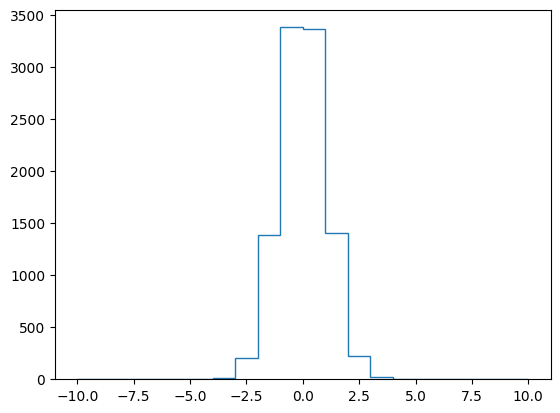

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = np.random.randn(10000)
data

bins = np.linspace(-10, 10, 21)
counts = np.zeros_like(bins) # 구간 0으로 초기화

i = np.searchsorted(bins, data) # (a,b) b가 어느 a에 속하는지 보는 것 == np.digitize(data, bins)
print(i)

np.add.at(counts, i, 1)
plt.hist(data, bins, histtype='step')

## 1. 난수 생성:

평균이 0, 표준편차가 1인 정규분포에서 난수 10,000개를 생성하여 data 배열에 저장.

In [37]:
data = np.random.randn(10000)

## 2. 구간 설정:

-10에서 10까지 20개의 구간을 균등하게 나누어 bins 배열.
이 구간들은 히스토그램의 각 구간 경계.

In [48]:
bins = np.linspace(-10, 10, 21)

## 3. 구간 인덱스 계산:

data의 각 값이 어느 구간에 속하는지 직접 계산하여 구간 인덱스 배열 indices에 저장.
예를 들어, data의 값이 특정 구간에 속하면 indices 배열에 그 구간 인덱스를 기록합니다.
이 과정에서 브로드캐스팅과 팬시 인덱싱을 활용하여 효율적으로 구간 인덱스를 계산.

In [49]:
fr = bins[:, None][:-1, :]
to = bins[:, None][1:, :]
ranges = np.concatenate([fr, to], axis=1)

# ranges[:, 0][:, None] <= data & data < ranges[:,1]
i = ((ranges[:, 0] <= data[:, None]) & (data[:, None] < ranges[:, 1]))

## 4. 누적 카운팅:

구한 indices 값을 사용하여, 각 구간별로 카운트를 계산.
팬시 인덱싱을 통해 indices에 해당하는 counts 위치에 1씩 누적.

In [53]:
idx = np.argmax(i, axis=1)
idx
counts = np.zeros_like(bins) # 구간 0으로 초기화
np.add.at(counts, idx, 1)

## 5. 결과 시각화:

구간별 빈도수를 그래프로 시각화하여 히스토그램.
bins와 counts를 사용하여 히스토그램이 올바르게 그려졌는지 확인.

(array([   0.,    0.,    0.,    0.,    0.,    0.,   15.,  218., 1403.,
        3384., 3412., 1353.,  199.,   16.,    0.,    0.,    0.,    0.,
           0.,    0.]),
 array([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,
          1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.]),
 <BarContainer object of 20 artists>)

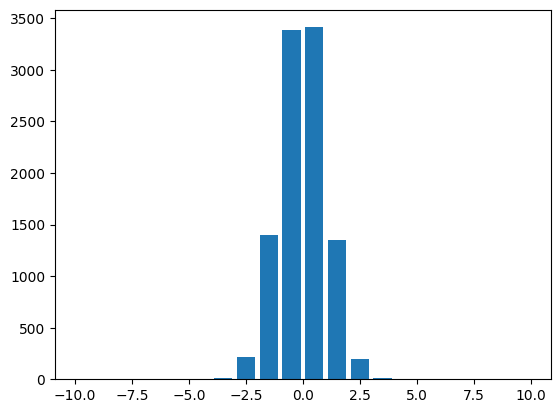

In [56]:
plt.hist(data, bins=bins, rwidth=0.8)